### Taller #1: Juan Guillermo Gutiérrz - 202122659

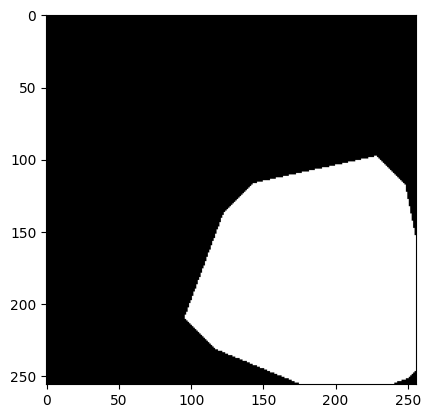

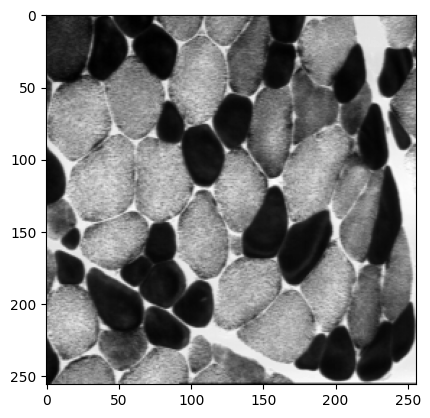

In [1]:
import cv2
import matplotlib.pyplot as plt

spotG = cv2.imread('SPOT.png', cv2.IMREAD_GRAYSCALE)
muscleG = cv2.imread('MUSCLE.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(spotG, cmap='gray')
plt.show()
plt.imshow(muscleG, cmap='gray')
plt.show()

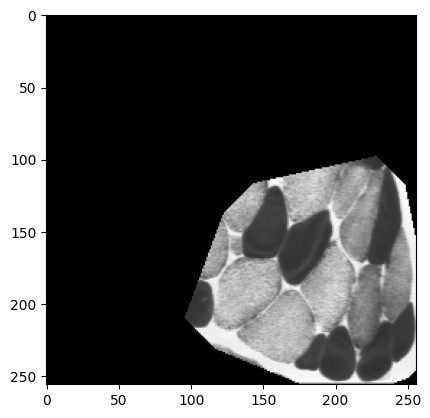

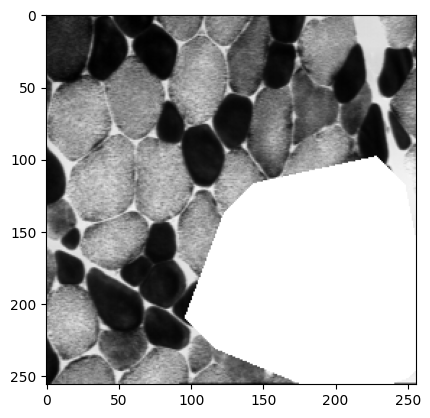

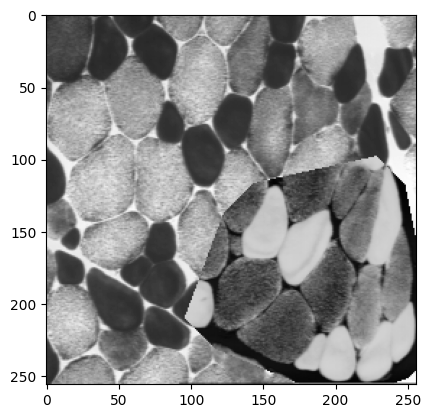

In [2]:
MSGand = cv2.bitwise_and(muscleG, spotG)
MSGor = cv2.bitwise_or(muscleG, spotG)
MSGxor = cv2.bitwise_xor(muscleG, spotG)

plt.imshow(MSGand, cmap='gray')
plt.show()
plt.imshow(MSGor, cmap='gray')
plt.show()
plt.imshow(MSGxor, cmap='gray')
plt.show()

# Conclusión:

1. Operación AND:   
La parte blanca de SPOT actúa como una ventana que deja ver la imagen MUSCLE, mientras que la parte negra de SPOT hace que esa región sea completamente negra en la imagen final. Como la imagen SPOT tiene una parte negra de valor 0 y una parte blanca de valor 255, la parte negra de SPOT anula la imagen MUSCLE en esa región, dejando solo la intersección donde ambas imágenes tienen valores altos.

2. Operación OR:    
La imagen SPOT se superpone sobre la imagen MUSCLE, manteniendo su área blanca intacta. Con esta operación, un píxel en la imagen resultante será blanco si al menos uno de los píxeles en las imágenes de entrada es blanco. Como la imagen SPOT tiene una sección blanca, esa sección sigue siendo blanca en la imagen resultante. 

3. Operación XOR:   
Las fibras de la imagen MUSCLE aún se ven, pero el fondo ha cambiado. Con esta operación, un píxel será blanco si es blanco en una imagen y negro en la otra. Entonces, podemos ver que la parte blanca de SPOT se invierte, volviéndose negra mientras que las diferencias entre las dos imágenes resaltan sobre las fibras del músculo.
  



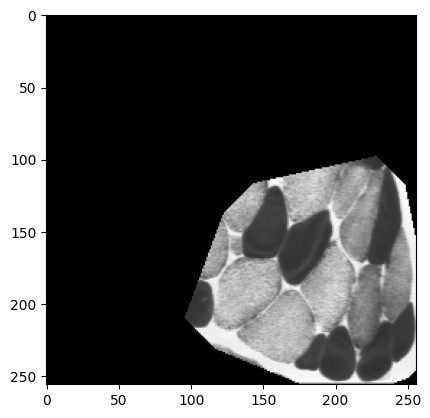

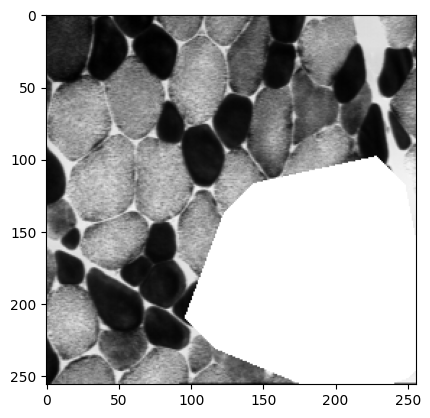

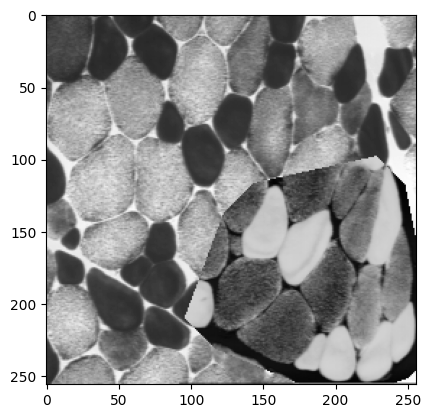

In [3]:
MSGand = cv2.bitwise_and(spotG, muscleG)
MSGor = cv2.bitwise_or(spotG, muscleG)
MSGxor = cv2.bitwise_xor(spotG, muscleG)

plt.imshow(MSGand, cmap='gray')
plt.show()
plt.imshow(MSGor, cmap='gray')
plt.show()
plt.imshow(MSGxor, cmap='gray')
plt.show()


# Conclusión:

Podemos ver que al invertir el orden de las imagenes a la hora de aplicar las operaciones, el resultado de estas es el mismo que en el punto anterior. Esto nos da a entender que estas operaciones son conmutativas.

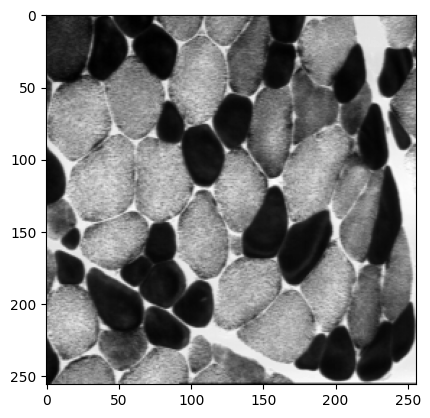

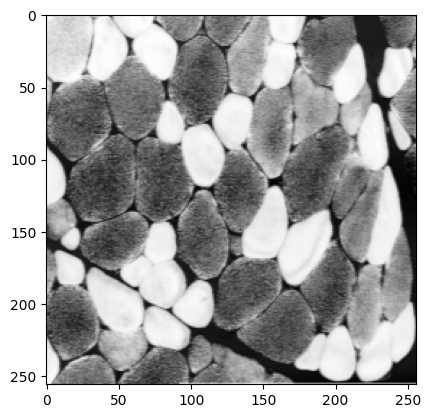

In [4]:
import numpy as np

imagen = np.full_like(muscleG, 255)
muscleGnot = cv2.bitwise_xor(muscleG, imagen)
plt.imshow(muscleG, cmap='gray')
plt.show()
plt.imshow(muscleGnot, cmap='gray')
plt.show()



# Explicación:

En el ejercicio número 3 del taller, pudimos ver la función de la operación NOT al sacar el negativo de la imagen de una regle. Al realizar ahora este ejercicio, sabemos que se puede conseguir el mismo resultado mediante la operación XOR con ayuda de una imagen auxiliar totalmente blanca. Esto es porqu XOR hace que solo los píxeles que sean diferentes en ambas imágenes permanezcan, de tal manera que si un píxel es blanco en una imagen y negro en la otra, se mantendrá blanco y si es negro en ambas o blanco en ambas, será negro.

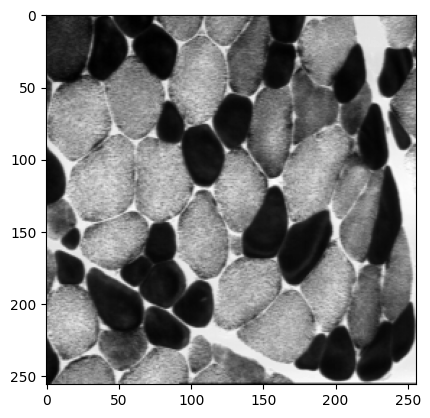

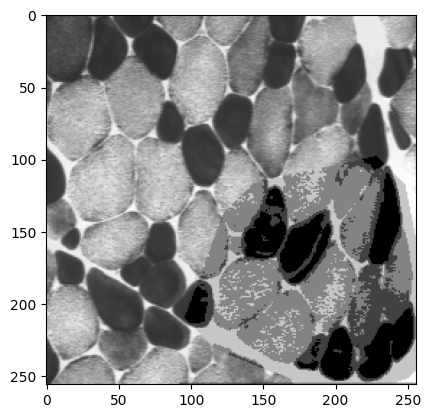

In [5]:
#1
_, mascara1 = cv2.threshold(spotG, 127, 255, cv2.THRESH_BINARY)

#2
mascara2 = 192  

#3
muscleGmod = muscleG.copy()

#4
muscleGmod[mascara1 == 255] &= mascara2 


plt.imshow(muscleG, cmap='gray')
plt.show()
plt.imshow(muscleGmod, cmap='gray')
plt.show()


# Explicación del Proceso:

1. Se crea una máscara binaria a partir de las zonas blancas de la imagen SPOT.
2. Se crea una máscara de bits para conservar solo los dos bits más significativos (192 es 11000000 en binario).
3. Se aplica la operación bitwise AND solo en la zona marcada por SPOT.
4. Se aplicará la máscara solo donde SPOT es blanco

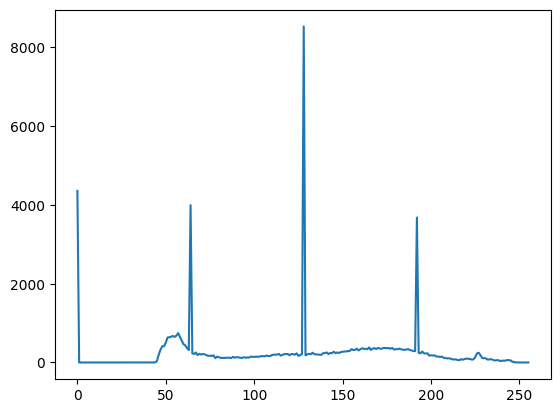

In [6]:
hist = cv2.calcHist([muscleGmod],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

Al generar el histograma de la imagen modificada podemos confirmar que se realizó la tarea correctamente, ya que se pueden apreciar los picos pronunciados en las intensidades 192, 128, 64 y 0.